The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


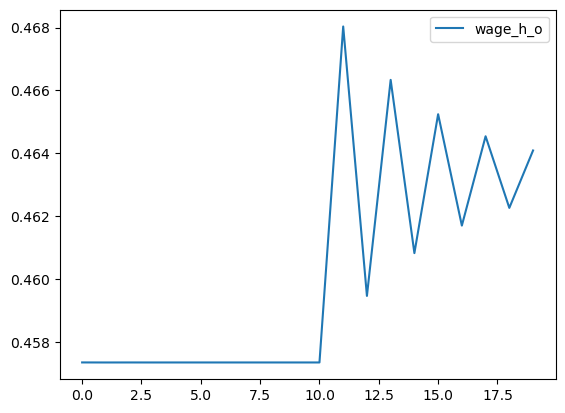

In [265]:
%load_ext autoreload
%autoreload 2

import numpy as np
from time import time
import matplotlib.pyplot as plt
from main import ModelClass

model = ModelClass()

model.solve()

parameter_names = ["rho_h"]
parameter_values = [0.9]

model.simulate(parameter_names, parameter_values)

# plt.plot(model.sim.l_h_o, label="l_h_o")
plt.plot(model.sim.l_l_o, label="wage_h_o")
plt.legend()
plt.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
rho_h=0.500, c=0.20, alpha=0.50 -> drop=0.000000
rho_h=0.500, c=0.20, alpha=0.70 -> drop=0.000000
rho_h=0.500, c=0.20, alpha=0.85 -> drop=0.000000
rho_h=0.500, c=0.20, alpha=0.90 -> drop=0.000000
rho_h=0.500, c=0.20, alpha=0.95 -> drop=0.000000
rho_h=0.500, c=0.20, alpha=0.97 -> drop=0.000000
rho_h=0.500, c=0.50, alpha=0.50 -> drop=0.000000
rho_h=0.500, c=0.50, alpha=0.70 -> drop=0.000000
rho_h=0.500, c=0.50, alpha=0.85 -> drop=0.000000
rho_h=0.500, c=0.50, alpha=0.90 -> drop=0.000000
rho_h=0.500, c=0.50, alpha=0.95 -> drop=0.000000
rho_h=0.500, c=0.50, alpha=0.97 -> drop=0.000000
rho_h=0.500, c=1.00, alpha=0.50 -> drop=0.000000
rho_h=0.500, c=1.00, alpha=0.70 -> drop=0.000000
rho_h=0.500, c=1.00, alpha=0.85 -> drop=0.000000
rho_h=0.500, c=1.00, alpha=0.90 -> drop=0.000000
rho_h=0.500, c=1.00, alpha=0.95 -> drop=0.000000
rho_h=0.500, c=1.00, alpha=0.97 -> drop=0.000000
rho_h=0.500, c=2.00, alpha=0.5

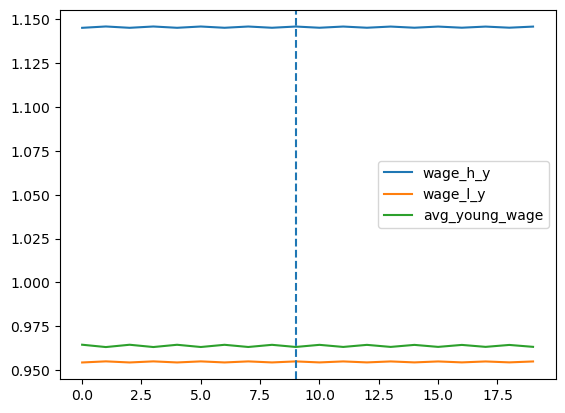

In [267]:
%load_ext autoreload
%autoreload 2

import numpy as np
import itertools
import matplotlib.pyplot as plt
from main import ModelClass


def avg_young_wage(sim, t):
    """Average young wage in period t."""
    # Young workers are split across high and low jobs.
    # This is the average wage among young workers.
    return (sim.wage_h_y[t] * sim.l_h_y[t] + sim.wage_l_y[t] * sim.l_l_y[t]) / (
        sim.l_h_y[t] + sim.l_l_y[t]
    )


def run_model_and_measure_drop(rho_h, c, alpha):
    model = ModelClass()

    # baseline parameters to search over
    model.par.rho_h = rho_h
    model.par.c = c
    model.par.alpha = alpha

    model.solve()

    # shock: change rho_h after T_shock - 1
    model.simulate(["rho_h"], [rho_h])

    # measure average young wage before and after shock
    pre_window = range(max(0, model.par.T_shock - 3), model.par.T_shock)
    post_window = range(model.par.T_shock, model.par.T)

    pre = np.mean([avg_young_wage(model.sim, t) for t in pre_window])
    post_min = np.min([avg_young_wage(model.sim, t) for t in post_window])

    # objective: maximize fall in young wage
    drop = pre - post_min

    return drop, pre, post_min, model


# parameter grids
rho_h_grid = np.linspace(0.50, 0.995, 10)
c_grid = np.array([0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 15.0])
alpha_grid = np.array([0.50, 0.70, 0.85, 0.90, 0.95, 0.97])

best = {
    "drop": -np.inf,
    "rho_h": None,
    "c": None,
    "alpha": None,
    "pre": None,
    "post_min": None,
    "model": None,
}

results = []

for rho_h, c, alpha in itertools.product(rho_h_grid, c_grid, alpha_grid):
    try:
        drop, pre, post_min, model = run_model_and_measure_drop(rho_h, c, alpha)
        results.append((drop, rho_h, c, alpha, pre, post_min))

        if np.isfinite(drop) and drop > best["drop"]:
            best.update({
                "drop": drop,
                "rho_h": rho_h,
                "c": c,
                "alpha": alpha,
                "pre": pre,
                "post_min": post_min,
                "model": model,
            })

        print(f"rho_h={rho_h:.3f}, c={c:.2f}, alpha={alpha:.2f} -> drop={drop:.6f}")
    except Exception as e:
        print(f"failed for rho_h={rho_h:.3f}, c={c:.2f}, alpha={alpha:.2f}: {e}")

print("\nBest combination:")
print(f"rho_h   = {best['rho_h']}")
print(f"c       = {best['c']}")
print(f"alpha   = {best['alpha']}")
print(f"pre     = {best['pre']}")
print(f"post_min= {best['post_min']}")
print(f"drop    = {best['drop']}")

# plot the best run
best_model = best["model"]
plt.plot(best_model.sim.wage_h_y, label="wage_h_y")
plt.plot(best_model.sim.wage_l_y, label="wage_l_y")
plt.plot([avg_young_wage(best_model.sim, t) for t in range(best_model.par.T)], label="avg_young_wage")
plt.axvline(best_model.par.T_shock - 1, linestyle="--")
plt.legend()
plt.show()

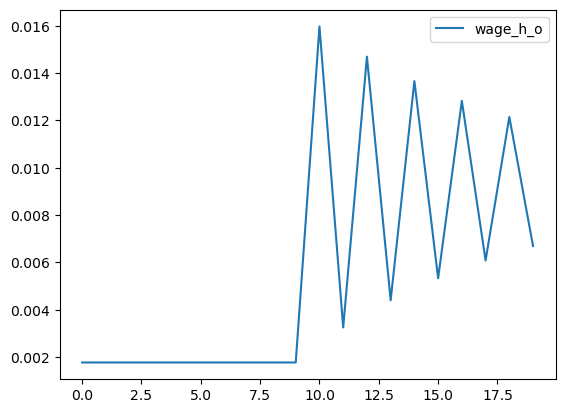

In [214]:
plt.plot(model.sim.l_h_o, label="wage_h_o")
plt.legend()
plt.show()

In [ ]:
theta_names = []

def obj_func(x):

    for name, value in zip(parameter_names, parameter_values):
        setattr(par, name, value)

    model.solve()

    parameter_names = ["rho_h"]
    parameter_values = [0.9]

    model.simulate(parameter_names, parameter_values)

    return model.sim.wage_h_o[11] - model.sim.wage_h_o[10]
    

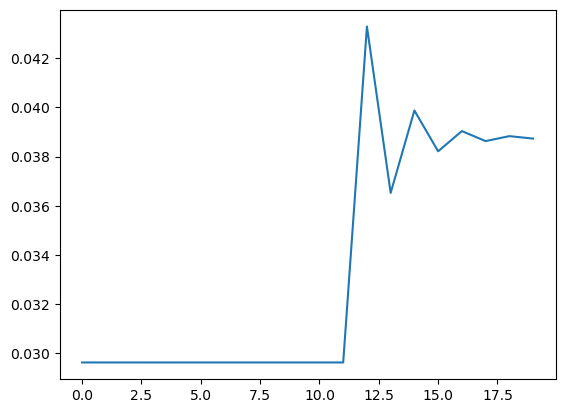

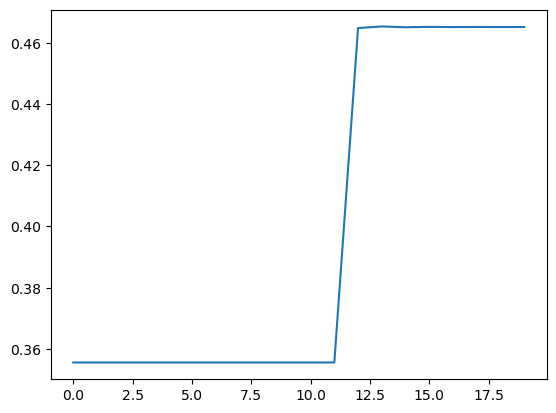

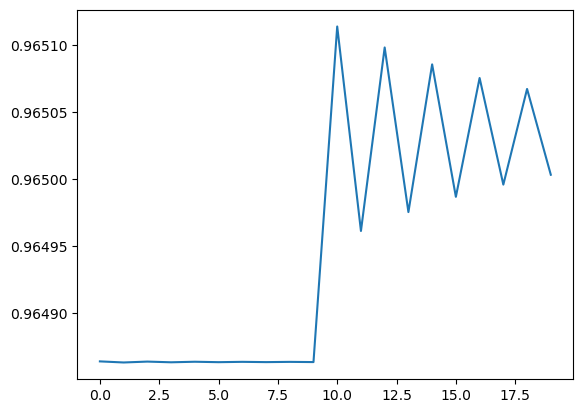

In [182]:
plt.plot(model.sim.wage_h_y)

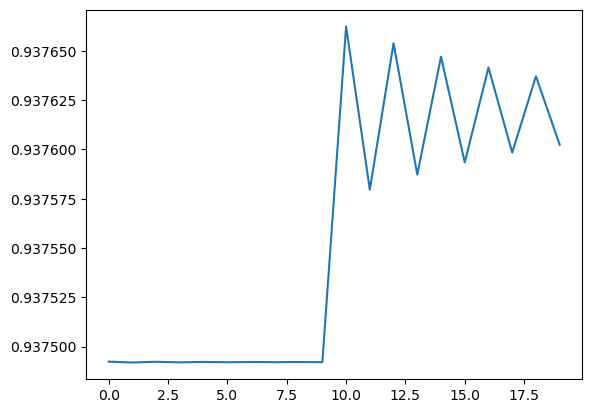

In [183]:
average_wage = model.sim.wage_l_y*model.sim.l_l_y/(model.sim.l_l_y + model.sim.l_h_y) + model.sim.wage_h_y*model.sim.l_h_y/(model.sim.l_l_y + model.sim.l_h_y)

plt.plot(average_wage)

In [178]:
average_wage

array([0.93573209, 0.93573423, 0.93573214, 0.9357342 , 0.93573218,
       0.93573414, 0.93573223, 0.9357341 , 0.93573228, 0.93573407,
       0.93572369, 0.93572944, 0.93572428, 0.93572892, 0.93572475,
       0.9357285 , 0.93572513, 0.93572817, 0.93572543, 0.93572788])

In [123]:
model.par.wage_l_o_ss

0.3555947228746009